# Sports Betting Forum: Influence Network Analysis
### Social Media Analytics — Network Analysis Project

**Research Questions:**
1. Who are the true opinion leaders in the sports betting community — and do active users = influential users?
2. What community structure emerges naturally from interaction patterns?
3. Is clustering driven by social influence or homophily?

**Data Source:** Covers.com forum posts (scraped: NFL, MLB, NHL threads)  
**Network Logic:** Directed edge from User A → User B when A quotes/replies to B. Edge weight = interaction frequency.

---
## 0. Setup & Imports

In [2]:
# Install required packages (run once)
import subprocess, sys
packages = ['networkx', 'python-louvain', 'matplotlib', 'seaborn', 'pandas', 'numpy', 'scipy']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages ready.')

All packages ready.


In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain   # python-louvain
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif'
})
SEED = 42
print('Imports complete.')

Imports complete.


---
## 1. Data Loading & Exploration

In [4]:
from google.colab import files
uploaded = files.upload()
DATA_PATH = list(uploaded.keys())[0]  # automatically uses whatever name Colab saved

df = pd.read_csv(DATA_PATH)
df = df[df['poster_name'] != 'PUSSYGALORE333']
print(f'Shape: {df.shape}')
df.head()

Saving covers_forum_posts_big data_250.csv to covers_forum_posts_big data_250.csv
Shape: (9702, 6)


,sport,post_number,poster_name,has_quote,quoted_user,post_text
0,NFL,1,Flynt,False,NaN,We are looking for your feedback! Tell us what...
1,NFL,1,Flynt,False,NaN,We are looking for your feedback! Tell us what...
2,NFL,1,fubah2,False,NaN,Starting off my 2022 NFL campaign with MNF. Hi...
3,NFL,2,baish2012,False,NaN,Yaa a bit too much chalk for me on this one bu...
4,NFL,3,fubah2,True,fubah2,YTD: 1 - 1 from MNF as Chiefs missed two makea...


In [5]:
df['sport'].value_counts()/len(df)

,count
sport,
NFL,0.431973
MLB,0.302000
NHL,0.266028


In [6]:
2*(0.431973*0.302000 + 0.302000*0.266028 + 0.431973*0.266028)

0.651426430488

In [7]:
print('=== Dataset Overview ===')
print(f'Total posts          : {len(df):,}')
print(f'Unique posters       : {df["poster_name"].nunique():,}')
print(f'Sports covered       : {sorted(df["sport"].unique())}')
print(f'Posts with a quote   : {df["has_quote"].eq(True).sum():,} ({df["has_quote"].eq(True).mean():.1%})')
print()
print('Posts per sport:')
print(df['sport'].value_counts().to_string())

=== Dataset Overview ===
Total posts          : 9,702
Unique posters       : 778
Sports covered       : ['MLB', 'NFL', 'NHL']
Posts with a quote   : 1,930 (19.9%)

Posts per sport:
sport
NFL    4191
MLB    2930
NHL    2581


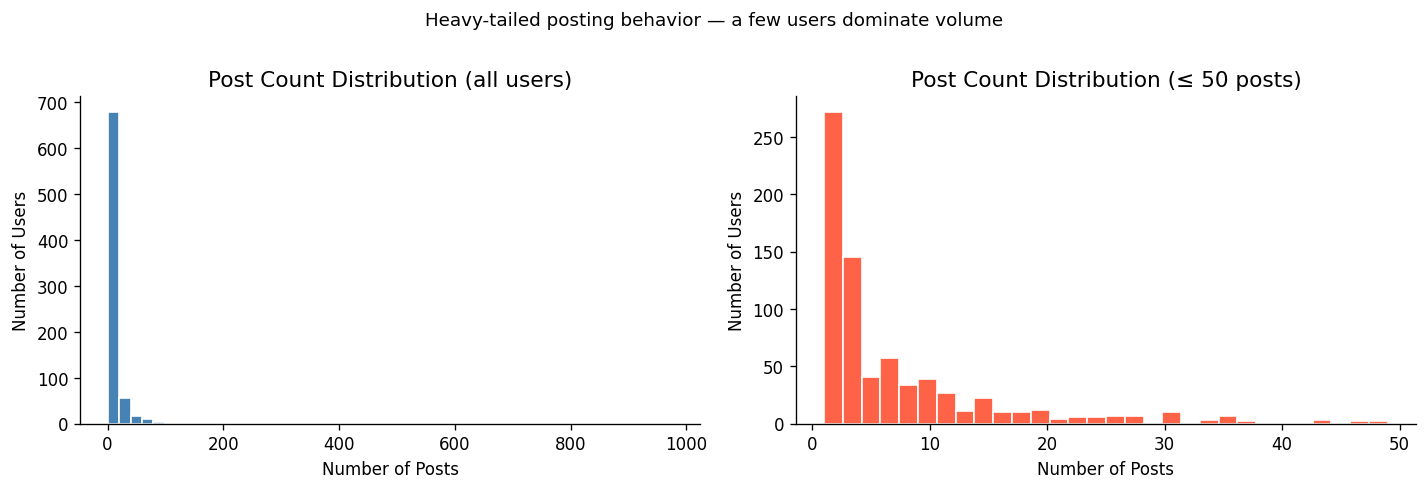

Top 10% of users account for 59.5% of all posts


In [8]:
# Distribution of post activity per user
post_counts = df['poster_name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(post_counts, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Post Count Distribution (all users)', fontsize=13)
axes[0].set_xlabel('Number of Posts')
axes[0].set_ylabel('Number of Users')

axes[1].hist(post_counts[post_counts <= 50], bins=30, color='tomato', edgecolor='white')
axes[1].set_title('Post Count Distribution (≤ 50 posts)', fontsize=13)
axes[1].set_xlabel('Number of Posts')
axes[1].set_ylabel('Number of Users')

plt.suptitle('Heavy-tailed posting behavior — a few users dominate volume', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print(f'Top 10% of users account for {post_counts[post_counts >= post_counts.quantile(0.9)].sum()/len(df):.1%} of all posts')

---
## 2. Network Construction

We build a **directed, weighted** interaction network:  
- **Node** = unique forum user  
- **Edge A → B** = user A quoted/replied to user B  
- **Edge weight** = number of times A quoted B  

Only posts with `has_quote == True` and a valid `quoted_user` contribute edges.

In [9]:
# Filter to reply/quote interactions only
replies = df[(df['has_quote'] == True) | (df['has_quote'] == 'True')].copy()
replies = replies[replies['quoted_user'].notna() & (replies['quoted_user'] != '')]

# Remove self-loops
replies = replies[replies['poster_name'] != replies['quoted_user']]

print(f'Reply interactions   : {len(replies):,}')
print(f'Unique source users  : {replies["poster_name"].nunique():,}')
print(f'Unique target users  : {replies["quoted_user"].nunique():,}')

Reply interactions   : 1,422
Unique source users  : 155
Unique target users  : 271


In [10]:
# Build weighted edge list
edge_weights = replies.groupby(['poster_name', 'quoted_user']).size().reset_index(name='weight')

# Create directed graph
G = nx.DiGraph()
for _, row in edge_weights.iterrows():
    G.add_edge(row['poster_name'], row['quoted_user'], weight=row['weight'])

# Add isolated posters as nodes (users who never quoted anyone)
for user in df['poster_name'].unique():
    if user not in G:
        G.add_node(user)

print('=== Graph Summary ===')
print(f'Nodes (users)        : {G.number_of_nodes():,}')
print(f'Edges (interactions) : {G.number_of_edges():,}')
print(f'Density              : {nx.density(G):.6f}')
print(f'Is strongly connected: {nx.is_strongly_connected(G)}')
print(f'Weakly connected components: {nx.number_weakly_connected_components(G):,}')

=== Graph Summary ===
Nodes (users)        : 785
Edges (interactions) : 501
Density              : 0.000814
Is strongly connected: False
Weakly connected components: 473


In [11]:
# Inspect the largest weakly connected component
components = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
print('Top 5 weakly connected components by size:')
for i, comp in enumerate(components[:5]):
    print(f'  Component {i+1}: {len(comp):,} nodes')

# Work with the largest weakly connected component for subsequent analysis
LCC_nodes = components[0]
G_lcc = G.subgraph(LCC_nodes).copy()
print(f'\nLargest connected component: {G_lcc.number_of_nodes():,} nodes, {G_lcc.number_of_edges():,} edges')

Top 5 weakly connected components by size:
  Component 1: 297 nodes
  Component 2: 4 nodes
  Component 3: 3 nodes
  Component 4: 3 nodes
  Component 5: 2 nodes

Largest connected component: 297 nodes, 485 edges


---
## 3. Network Structure Analysis

Before influence analysis, we characterize the macro-level structure of the community.

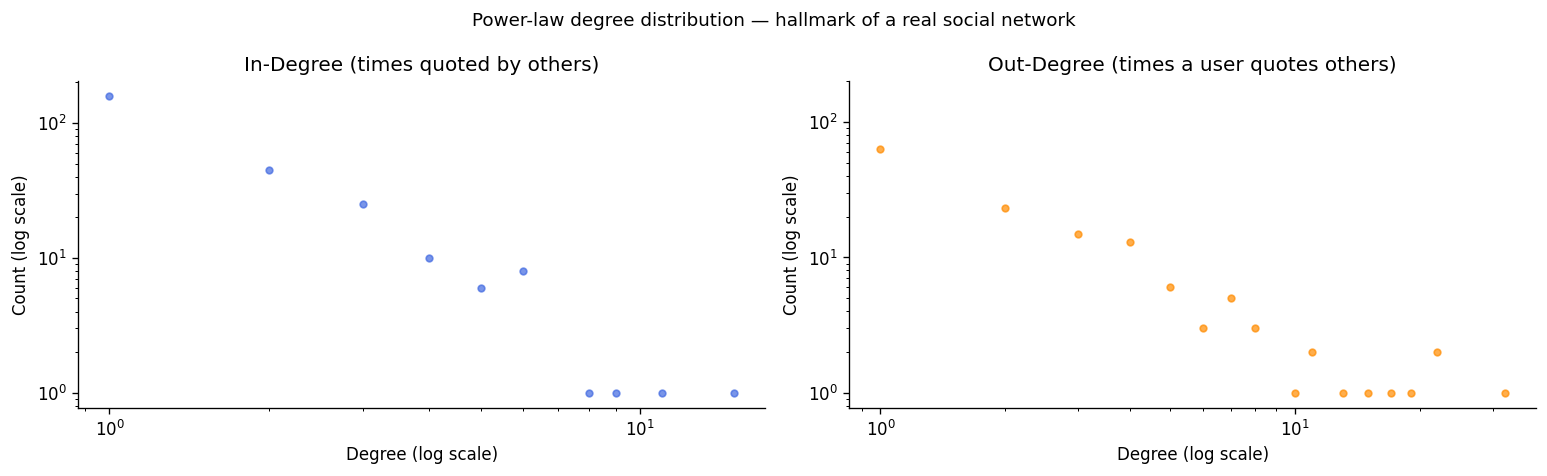

In [12]:
# ── Degree distribution (in- and out-degree) ─────────────────────────────────
in_degrees  = dict(G_lcc.in_degree())
out_degrees = dict(G_lcc.out_degree())

in_deg_vals  = list(in_degrees.values())
out_deg_vals = list(out_degrees.values())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, vals, label, color in zip(
        axes,
        [in_deg_vals, out_deg_vals],
        ['In-Degree (times quoted by others)', 'Out-Degree (times a user quotes others)'],
        ['royalblue', 'darkorange']):
    counter = Counter(vals)
    x, y = zip(*sorted(counter.items()))
    ax.loglog(x, y, 'o', markersize=4, color=color, alpha=0.7)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Degree (log scale)')
    ax.set_ylabel('Count (log scale)')

plt.suptitle('Power-law degree distribution — hallmark of a real social network', fontsize=11)
plt.tight_layout()
plt.show()

In [13]:
# ── Clustering coefficient & reciprocity ────────────────────────────────────
G_undirected = G_lcc.to_undirected()
avg_clustering = nx.average_clustering(G_undirected)
reciprocity    = nx.overall_reciprocity(G_lcc)

# Average shortest path on a sample (full computation is expensive)
sample_nodes = list(G_lcc.nodes())[:300]
sub = G_lcc.subgraph(sample_nodes)
# Largest strongly connected component of the sample
scc = max(nx.strongly_connected_components(sub), key=len)
sub_scc = sub.subgraph(scc)
avg_path = nx.average_shortest_path_length(sub_scc) if len(scc) > 1 else float('nan')

print('=== Structural Properties (Largest Weakly Connected Component) ===')
print(f'Nodes                    : {G_lcc.number_of_nodes():,}')
print(f'Edges                    : {G_lcc.number_of_edges():,}')
print(f'Density                  : {nx.density(G_lcc):.5f}')
print(f'Average clustering coeff : {avg_clustering:.4f}')
print(f'Reciprocity              : {reciprocity:.4f}')
print(f'Avg shortest path (sample of 300): {avg_path:.3f}')

=== Structural Properties (Largest Weakly Connected Component) ===
Nodes                    : 297
Edges                    : 485
Density                  : 0.00552
Average clustering coeff : 0.0592
Reciprocity              : 0.2144
Avg shortest path (sample of 300): 4.539


---
## 4. Centrality Analysis

We compute all four centrality metrics and compare them to raw post volume.  
**Key question:** Does being *active* (high post count / high degree) translate to being *influential* (high betweenness, high PageRank)?

In [14]:
print('Computing centrality metrics... (may take ~30s)')

# 1. Degree centrality (normalized)
in_deg_centrality  = nx.in_degree_centrality(G_lcc)
out_deg_centrality = nx.out_degree_centrality(G_lcc)

# 2. Betweenness centrality (uses weight; k=500 approximation for speed)
betweenness = nx.betweenness_centrality(G_lcc, k=min(500, G_lcc.number_of_nodes()),
                                         weight='weight', normalized=True, seed=SEED)

# 3. Closeness centrality
closeness = nx.closeness_centrality(G_lcc)

# 4. PageRank
pagerank = nx.pagerank(G_lcc, weight='weight', alpha=0.85)

# 5. Raw post count (volume)
post_count = df['poster_name'].value_counts().to_dict()

# Assemble into DataFrame
nodes = list(G_lcc.nodes())
centrality_df = pd.DataFrame({
    'user'          : nodes,
    'post_count'    : [post_count.get(n, 0) for n in nodes],
    'in_degree'     : [in_deg_centrality[n]  for n in nodes],
    'out_degree'    : [out_deg_centrality[n] for n in nodes],
    'betweenness'   : [betweenness[n]        for n in nodes],
    'closeness'     : [closeness[n]          for n in nodes],
    'pagerank'      : [pagerank[n]           for n in nodes],
})

print('Done.')
centrality_df.sort_values('pagerank', ascending=False).head(10)

Computing centrality metrics... (may take ~30s)
Done.


,user,post_count,in_degree,out_degree,betweenness,closeness,pagerank
219,fubah2,975,0.050676,0.108108,0.065514,0.089878,0.031676
175,Midnight1,143,0.030405,0.013514,0.004058,0.073909,0.028009
164,KellyM_1964,230,0.016892,0.043919,0.015160,0.072912,0.016661
209,lovethedough,27,0.010135,0.000000,0.000000,0.062795,0.015398
174,Europa,64,0.027027,0.033784,0.089017,0.106380,0.013636
22,MrBator,122,0.037162,0.074324,0.092569,0.112270,0.012347
290,StumpTownStu,35,0.013514,0.013514,0.008203,0.083409,0.011478
122,tryn2makeabuck,6,0.003378,0.006757,0.007593,0.044753,0.011317
112,fullblown,7,0.006757,0.003378,0.006161,0.051666,0.011235
206,DJK,58,0.020270,0.074324,0.045328,0.092968,0.010552


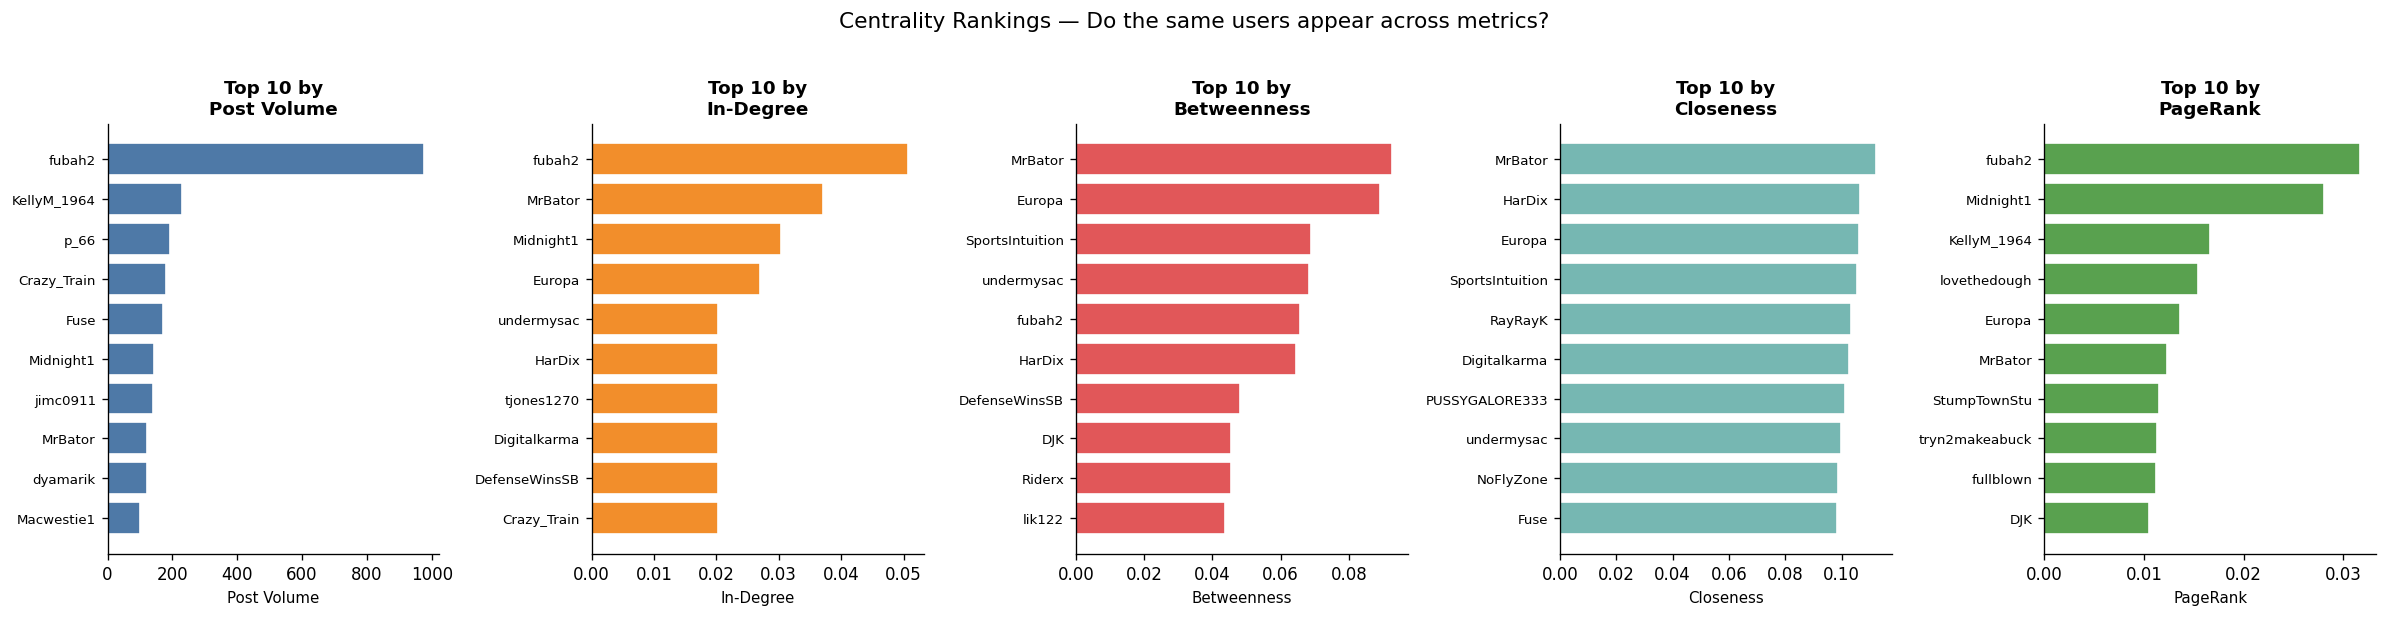

In [15]:
# ── Top-10 users per metric ───────────────────────────────────────────────────
metrics = ['post_count', 'in_degree', 'betweenness', 'closeness', 'pagerank']
labels  = ['Post Volume', 'In-Degree', 'Betweenness', 'Closeness', 'PageRank']

fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))

colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']

for ax, metric, label, color in zip(axes, metrics, labels, colors):
    top10 = centrality_df.nlargest(10, metric)[['user', metric]]
    ax.barh(top10['user'][::-1], top10[metric][::-1], color=color, edgecolor='white')
    ax.set_title(f'Top 10 by\n{label}', fontsize=11, fontweight='bold')
    ax.set_xlabel(label, fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Centrality Rankings — Do the same users appear across metrics?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

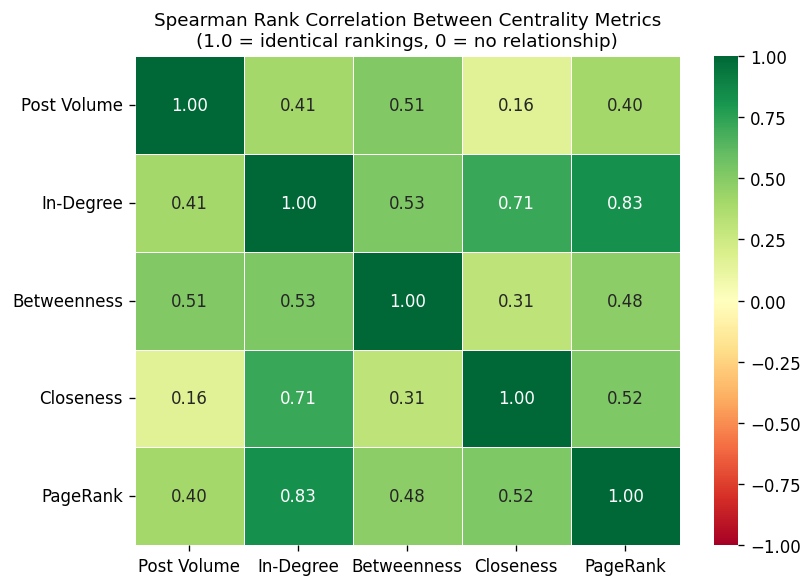


Key finding:
  Post Volume vs Betweenness (Spearman r = 0.508)
  → Strong correlation: active users also tend to be bridge accounts.


In [16]:
# ── Rank correlation matrix: does activity = influence? ──────────────────────
rank_corr = centrality_df[metrics].rank(ascending=False).corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(rank_corr, dtype=bool), k=1)
sns.heatmap(rank_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            xticklabels=labels, yticklabels=labels)
ax.set_title("Spearman Rank Correlation Between Centrality Metrics\n"
             "(1.0 = identical rankings, 0 = no relationship)", fontsize=11)
plt.tight_layout()
plt.show()

print('\nKey finding:')
r = rank_corr.loc['post_count', 'betweenness']
print(f'  Post Volume vs Betweenness (Spearman r = {r:.3f})')
if abs(r) < 0.5:
    print('  → Weak correlation: high-volume posters are NOT necessarily the bridge accounts.')
else:
    print('  → Strong correlation: active users also tend to be bridge accounts.')

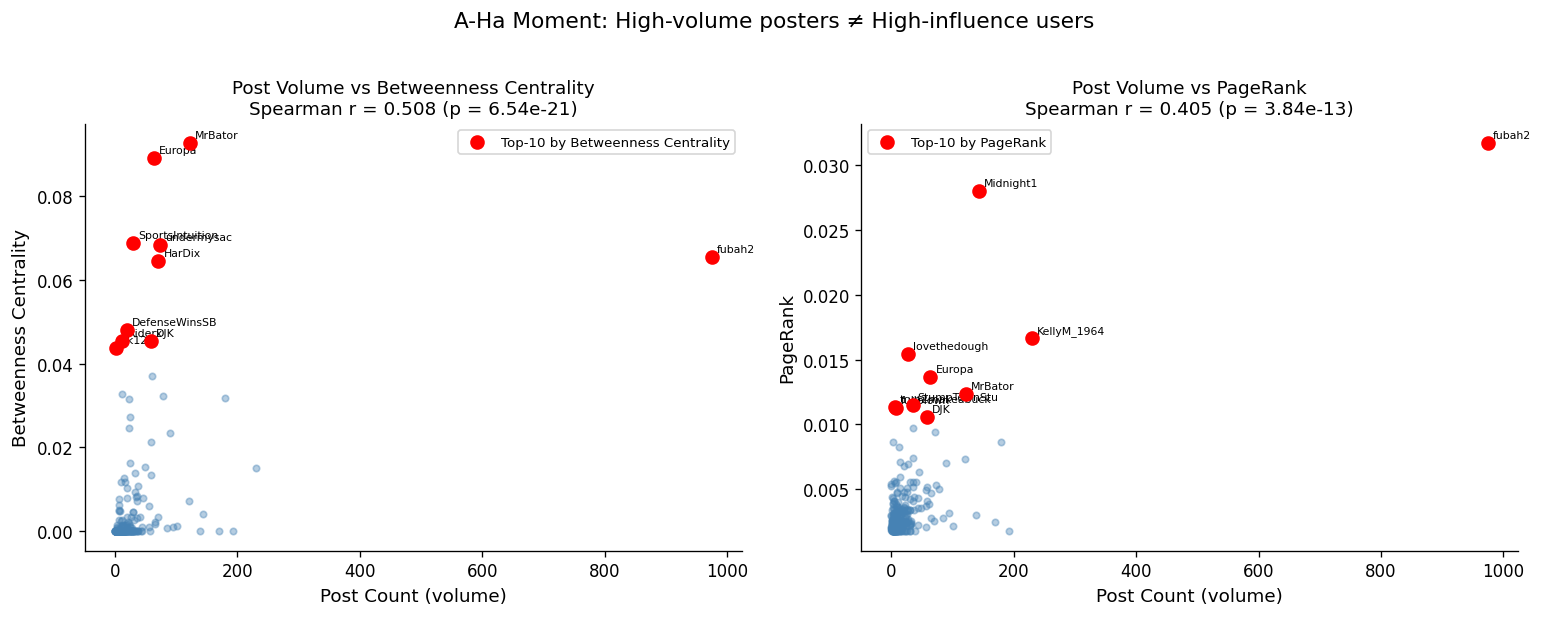

In [17]:
# ── Scatter: Post Volume vs Betweenness ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_col, y_label in zip(
        axes,
        ['betweenness', 'pagerank'],
        ['Betweenness Centrality', 'PageRank']):

    ax.scatter(centrality_df['post_count'], centrality_df[y_col],
               alpha=0.4, s=15, color='steelblue')

    # Highlight top-10 by y_col
    top = centrality_df.nlargest(10, y_col)
    ax.scatter(top['post_count'], top[y_col], color='red', s=60, zorder=5, label='Top-10 by ' + y_label)
    for _, row in top.iterrows():
        ax.annotate(row['user'], (row['post_count'], row[y_col]),
                    fontsize=6.5, xytext=(3, 3), textcoords='offset points')

    r, p = stats.spearmanr(centrality_df['post_count'], centrality_df[y_col])
    ax.set_xlabel('Post Count (volume)', fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(f'Post Volume vs {y_label}\nSpearman r = {r:.3f} (p = {p:.3g})', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('A-Ha Moment: High-volume posters ≠ High-influence users', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Community Detection (Louvain Algorithm)

We apply Louvain community detection to discover organic clusters.  
**Hypothesis:** We'll see structurally distinct groups (e.g., sharp analytical bettors vs. casual/fan bettors) emerge purely from interaction patterns.

In [18]:
import subprocess
subprocess.check_call(["pip", "install", "python-louvain", "--break-system-packages", "-q"])

0

In [20]:
from community import community_louvain # Ensure correct import of the submodule

# Louvain works on undirected graphs
G_undir = G_lcc.to_undirected()

partition = community_louvain.best_partition(G_undir, weight='weight', random_state=SEED)

community_ids = list(partition.values())
n_communities = max(community_ids) + 1
modularity = community_louvain.modularity(partition, G_undir, weight='weight')

print(f'Communities detected : {n_communities}')
print(f'Modularity score     : {modularity:.4f}  (>0.3 = strong structure)')

# Community sizes
comm_sizes = Counter(community_ids)
print('\nCommunity sizes (descending):')
for cid, size in sorted(comm_sizes.items(), key=lambda x: -x[1]):
    print(f'  Community {cid}: {size:,} members')

Communities detected : 13
Modularity score     : 0.6442  (>0.3 = strong structure)

Community sizes (descending):
  Community 2: 53 members
  Community 1: 44 members
  Community 9: 38 members
  Community 12: 38 members
  Community 11: 33 members
  Community 8: 27 members
  Community 6: 22 members
  Community 7: 14 members
  Community 10: 8 members
  Community 4: 7 members
  Community 5: 5 members
  Community 3: 4 members
  Community 0: 4 members


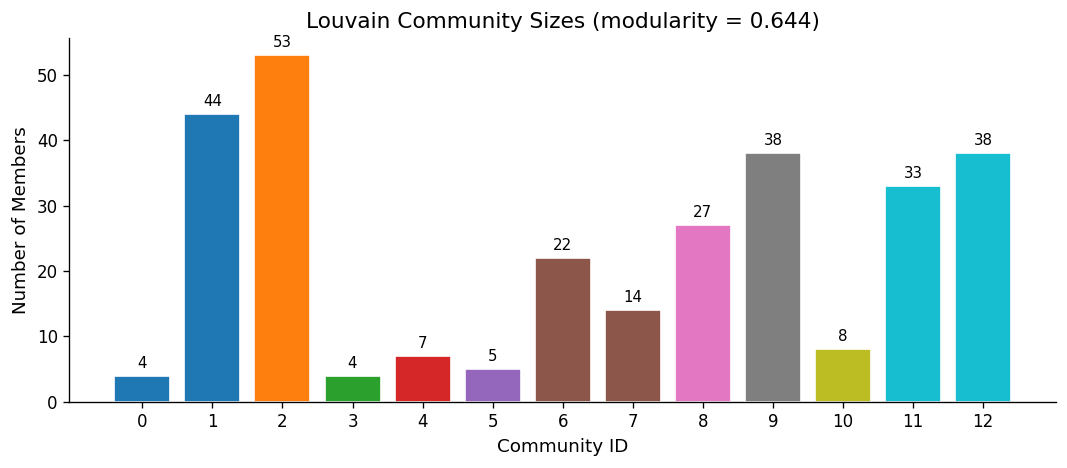

In [21]:
# Add community labels to centrality_df
centrality_df['community'] = centrality_df['user'].map(partition)

# ── Community size bar chart ─────────────────────────────────────────────────
comm_size_df = centrality_df['community'].value_counts().reset_index()
comm_size_df.columns = ['community', 'size']
comm_size_df = comm_size_df.sort_values('community')

palette = plt.cm.tab10(np.linspace(0, 1, len(comm_size_df)))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(comm_size_df['community'].astype(str), comm_size_df['size'],
              color=palette, edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Community ID', fontsize=11)
ax.set_ylabel('Number of Members', fontsize=11)
ax.set_title(f'Louvain Community Sizes (modularity = {modularity:.3f})', fontsize=13)
plt.tight_layout()
plt.show()

Visualization subgraph: 241 nodes, 429 edges


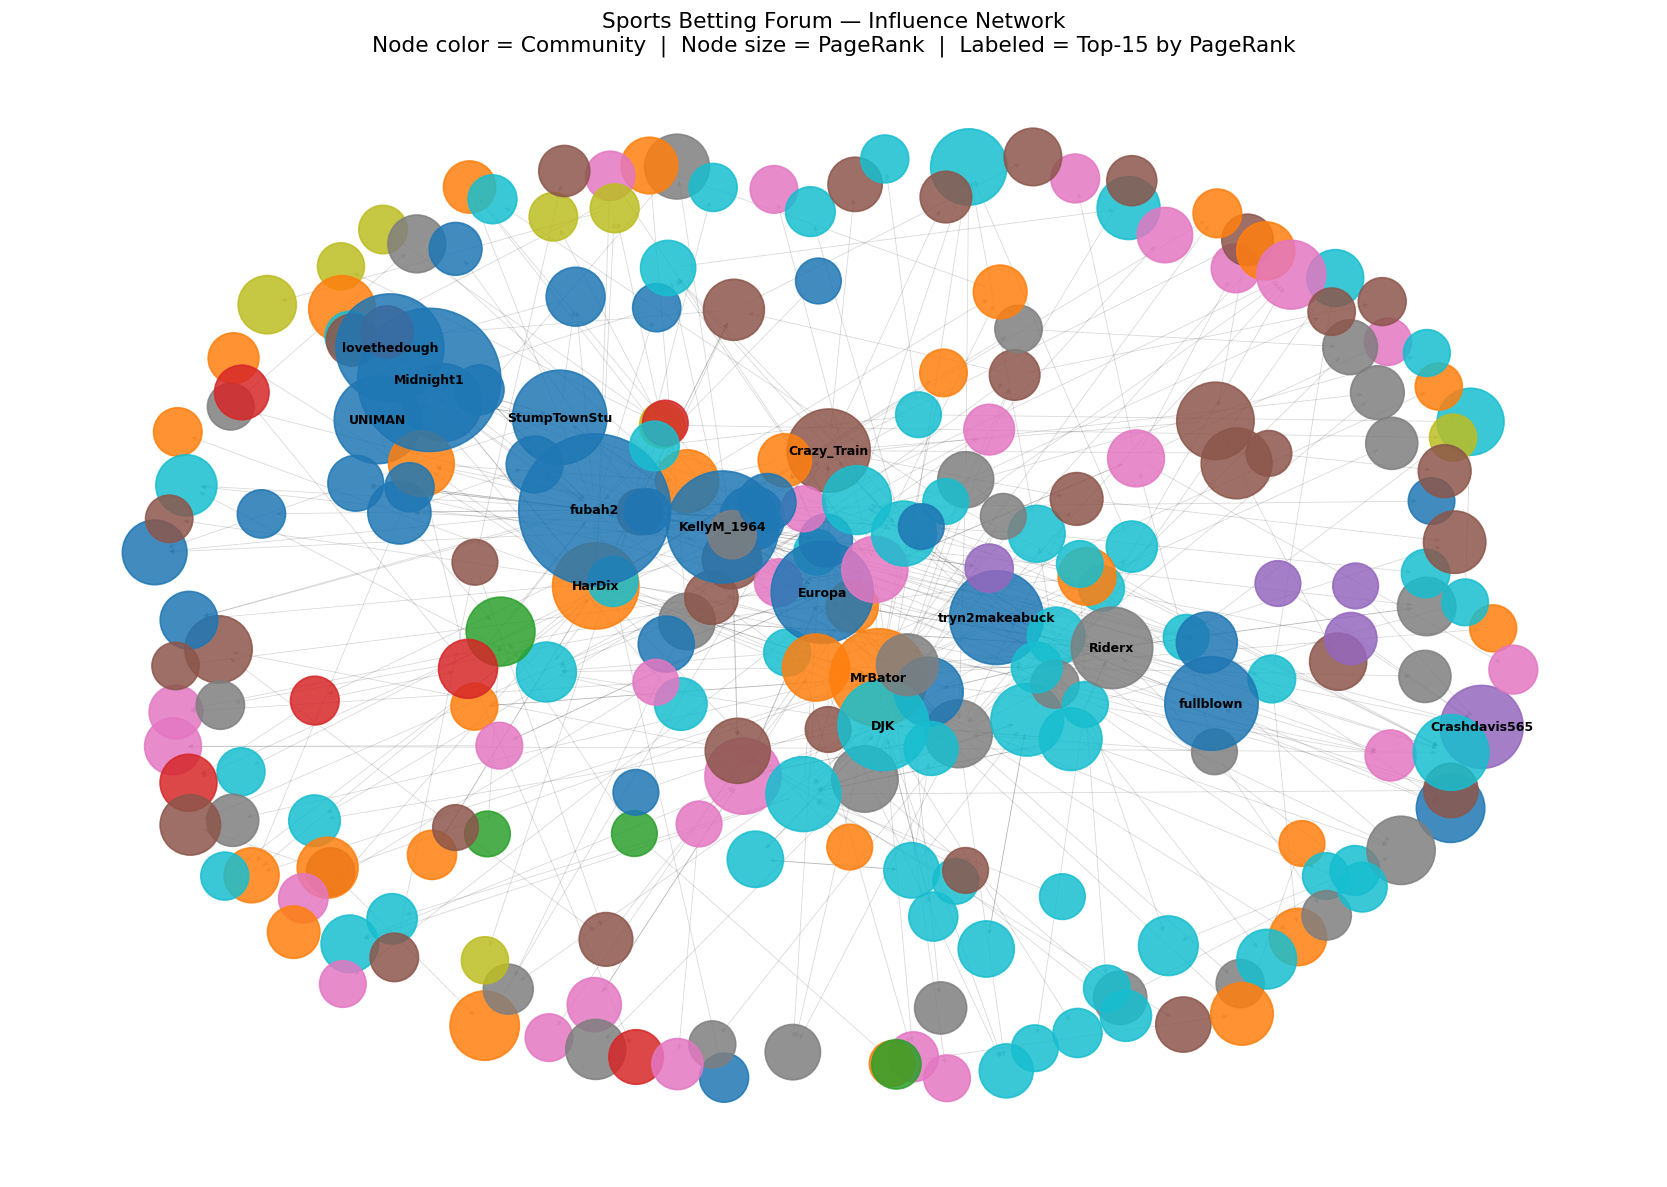

In [22]:
# ── Network visualization colored by community ───────────────────────────────
# Use a manageable subgraph for visualization
# Keep top-N most connected nodes per community + bridge nodes
top_n_per_comm = 30
viz_nodes = set()

for cid in range(n_communities):
    comm_nodes = [n for n, c in partition.items() if c == cid]
    # Sort by degree within community
    by_deg = sorted(comm_nodes, key=lambda n: G_lcc.degree(n), reverse=True)
    viz_nodes.update(by_deg[:top_n_per_comm])

# Add top betweenness nodes (bridges)
top_between = centrality_df.nlargest(20, 'betweenness')['user'].tolist()
viz_nodes.update(top_between)

G_viz = G_lcc.subgraph(viz_nodes).copy()
print(f'Visualization subgraph: {G_viz.number_of_nodes()} nodes, {G_viz.number_of_edges()} edges')

# Layout
pos = nx.spring_layout(G_viz, seed=SEED, k=0.4, weight='weight')

# Colors
color_map = plt.cm.tab10
node_colors = [color_map(partition.get(n, 0) / max(1, n_communities - 1)) for n in G_viz.nodes()]

# Node sizes by PageRank
pr_vals = np.array([pagerank.get(n, 0) for n in G_viz.nodes()])
node_sizes = 300 + 8000 * (pr_vals / pr_vals.max())

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(G_viz, pos, alpha=0.15, width=0.5, arrows=True,
                       arrowsize=6, ax=ax)
nx.draw_networkx_nodes(G_viz, pos, node_color=node_colors, node_size=node_sizes,
                       alpha=0.85, ax=ax)

# Label only the highest-PageRank nodes
top_pr_nodes = centrality_df.nlargest(15, 'pagerank')['user'].tolist()
labels_to_show = {n: n for n in G_viz.nodes() if n in top_pr_nodes}
nx.draw_networkx_labels(G_viz, pos, labels=labels_to_show, font_size=7.5, font_weight='bold', ax=ax)

ax.set_title('Sports Betting Forum — Influence Network\n'
             'Node color = Community  |  Node size = PageRank  |  Labeled = Top-15 by PageRank',
             fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

In [23]:
# ── Community-level centrality comparison ─────────────────────────────────────
comm_stats = centrality_df.groupby('community').agg(
    size         = ('user', 'count'),
    avg_pagerank = ('pagerank', 'mean'),
    avg_between  = ('betweenness', 'mean'),
    avg_posts    = ('post_count', 'mean'),
    top_user     = ('pagerank', lambda x: centrality_df.loc[x.idxmax(), 'user'])
).reset_index()

print('Community-level summary:')
print(comm_stats.to_string(index=False))

Community-level summary:
 community  size  avg_pagerank  avg_between  avg_posts        top_user
         0     4      0.002975     0.017215  16.250000 SportsIntuition
         1    44      0.005650     0.005834  47.477273          fubah2
         2    53      0.003027     0.004972  13.792453         MrBator
         3     4      0.002844     0.001779  60.000000      Barbarossa
         4     7      0.002837     0.004462  12.285714    SirJohnDrake
         5     5      0.003390     0.000250   5.800000   Crashdavis565
         6    22      0.003499     0.002357  38.909091     Crazy_Train
         7    14      0.002636     0.003745  14.571429        tweets50
         8    27      0.002721     0.002405  19.555556    Digitalkarma
         9    38      0.002968     0.004075  10.105263          Riderx
        10     8      0.002224     0.000143  25.000000 EastsideBangers
        11    33      0.002631     0.002794  17.606061           umgmu
        12    38      0.003320     0.003773  16.2631

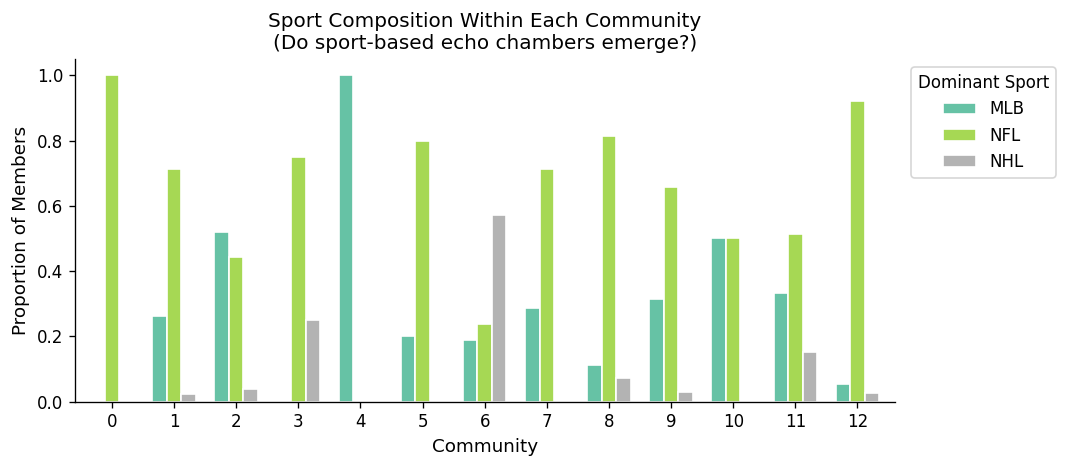

In [24]:
# ── Sport-community alignment: do sports cluster separately? ─────────────────
# Build a sport-affiliation lookup per user
sport_affinity = df.groupby('poster_name')['sport'].agg(
    lambda x: x.value_counts().index[0]  # dominant sport
).reset_index()
sport_affinity.columns = ['user', 'dominant_sport']

centrality_df = centrality_df.merge(sport_affinity, on='user', how='left')

# Cross-tabulation
ct = pd.crosstab(centrality_df['community'], centrality_df['dominant_sport'],
                 normalize='index').round(3)

fig, ax = plt.subplots(figsize=(9, 4))
ct.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.7)
ax.set_xlabel('Community', fontsize=11)
ax.set_ylabel('Proportion of Members', fontsize=11)
ax.set_title('Sport Composition Within Each Community\n'
             '(Do sport-based echo chambers emerge?)', fontsize=12)
ax.legend(title='Dominant Sport', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

---
## 6. Homophily vs. Social Influence

**Homophily:** Users cluster because they were *already similar* (same sport preference, same posting style).  
**Social influence:** Users become similar *because* they interact with influential nodes.

We use two proxies:  
1. **Within-community edge ratio** — high ratio suggests homophily-driven clustering.  
2. **Post volume convergence near high-PageRank nodes** — users who interact heavily with top influencers show similar activity patterns (descriptive proxy for influence).

Within-community edges : 380 / 485 = 78.4%
Cross-community edges  : 105 = 21.6%


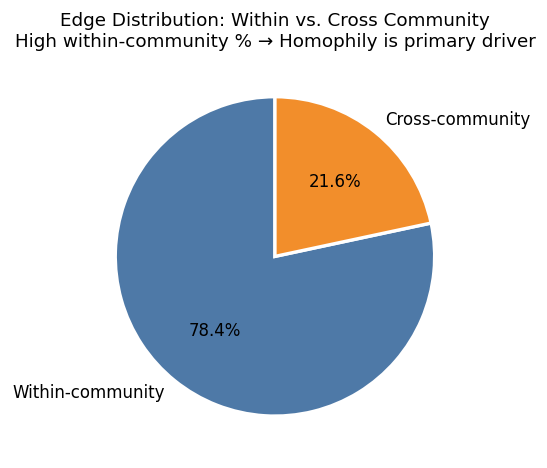

In [25]:
# ── Within-community edge ratio ───────────────────────────────────────────────
within_edges = 0
total_edges  = G_lcc.number_of_edges()

for u, v in G_lcc.edges():
    if partition.get(u) == partition.get(v):
        within_edges += 1

within_ratio = within_edges / total_edges
print(f'Within-community edges : {within_edges:,} / {total_edges:,} = {within_ratio:.1%}')
print(f'Cross-community edges  : {total_edges - within_edges:,} = {1 - within_ratio:.1%}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie([within_ratio, 1 - within_ratio],
       labels=['Within-community', 'Cross-community'],
       colors=['#4e79a7', '#f28e2b'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Edge Distribution: Within vs. Cross Community\n'
             'High within-community % → Homophily is primary driver', fontsize=11)
plt.tight_layout()
plt.show()

Top 5 influencers (PageRank): ['fubah2', 'Midnight1', 'KellyM_1964', 'lovethedough', 'Europa']


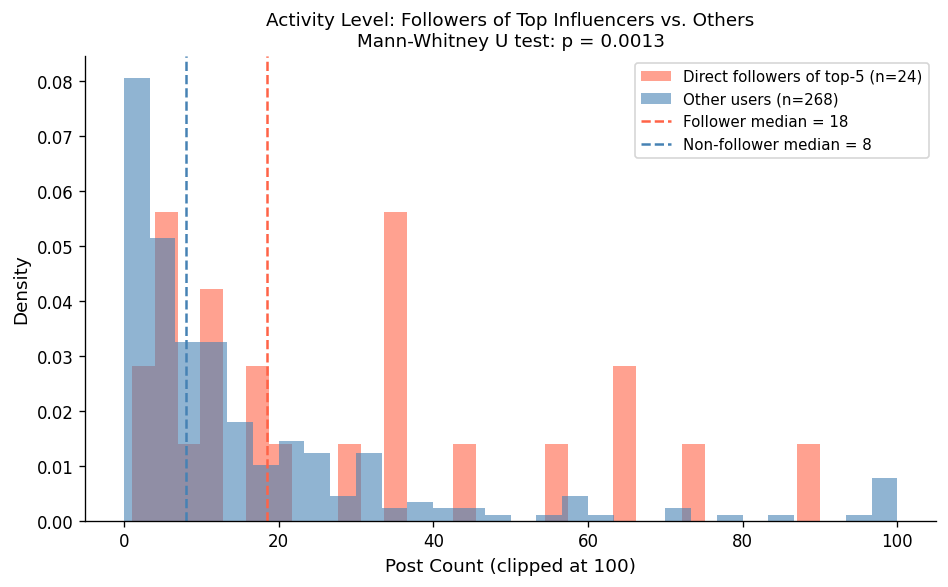


Mann-Whitney U = 4404, p = 0.0013
Interpretation: Users who engage with top influencers ARE significantly more active


In [26]:
# ── Social influence proxy: do users who interact with top influencers post more? ──
# Identify top-5 influencers by PageRank
top5_influencers = centrality_df.nlargest(5, 'pagerank')['user'].tolist()
print('Top 5 influencers (PageRank):', top5_influencers)

# For each influencer, get their direct followers (users who replied TO them)
influencer_followers = {}
for inf in top5_influencers:
    if inf in G_lcc:
        followers = list(G_lcc.predecessors(inf))  # nodes that point TO influencer
        influencer_followers[inf] = followers

# Compare post counts: direct followers vs. non-followers
all_followers = set(u for followers in influencer_followers.values() for u in followers)
all_followers -= set(top5_influencers)  # exclude influencers themselves

follower_posts    = centrality_df[centrality_df['user'].isin(all_followers)]['post_count']
non_follower_posts = centrality_df[~centrality_df['user'].isin(all_followers | set(top5_influencers))]['post_count']

t_stat, p_val = stats.mannwhitneyu(follower_posts, non_follower_posts, alternative='greater')

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(follower_posts.clip(upper=100),    bins=30, alpha=0.6, color='tomato',
        label=f'Direct followers of top-5 (n={len(follower_posts):,})', density=True)
ax.hist(non_follower_posts.clip(upper=100), bins=30, alpha=0.6, color='steelblue',
        label=f'Other users (n={len(non_follower_posts):,})', density=True)
ax.axvline(follower_posts.median(), color='tomato', linestyle='--', linewidth=1.5,
           label=f'Follower median = {follower_posts.median():.0f}')
ax.axvline(non_follower_posts.median(), color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Non-follower median = {non_follower_posts.median():.0f}')
ax.set_xlabel('Post Count (clipped at 100)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Activity Level: Followers of Top Influencers vs. Others\n'
             f'Mann-Whitney U test: p = {p_val:.4f}', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'\nMann-Whitney U = {t_stat:.0f}, p = {p_val:.4f}')
print('Interpretation:', 'Users who engage with top influencers ARE significantly more active'
      if p_val < 0.05 else 'No significant difference — activity is not tied to influencer proximity')

In [27]:
# ── Assortativity: do similar-degree users interact with each other? ──────────
degree_assortativity = nx.degree_assortativity_coefficient(G_lcc)
print(f'Degree assortativity coefficient: {degree_assortativity:.4f}')
if degree_assortativity > 0:
    print('  → ASSORTATIVE: High-degree users connect with other high-degree users (hub-to-hub).')
elif degree_assortativity < 0:
    print('  → DISASSORTATIVE: High-degree users connect with low-degree users (hub-and-spoke).')
else:
    print('  → NEUTRAL: No preference.')

Degree assortativity coefficient: -0.1686
  → DISASSORTATIVE: High-degree users connect with low-degree users (hub-and-spoke).


---
## 7. Results Summary & Key Findings

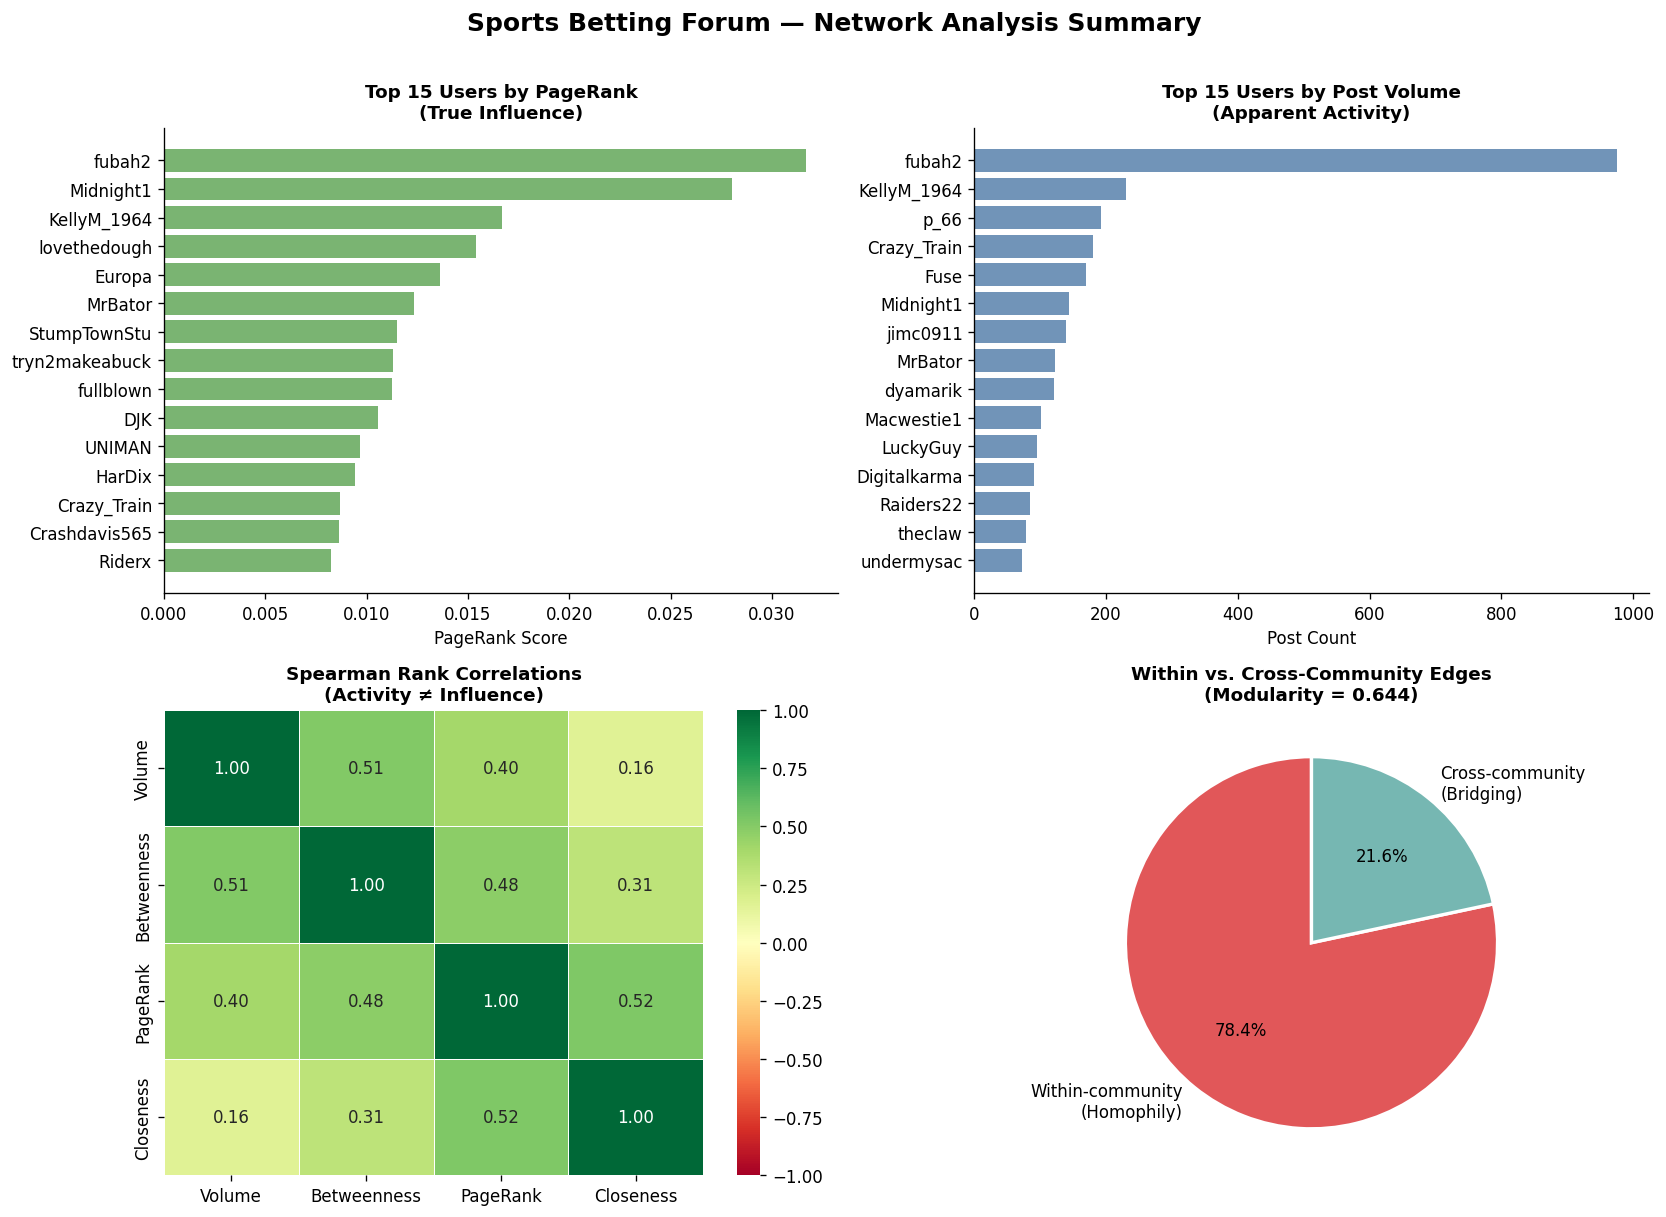

In [28]:
# ── Final summary visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Top 10 by PageRank vs Post Count
ax1 = axes[0, 0]
top15 = centrality_df.nlargest(15, 'pagerank')[['user', 'pagerank', 'post_count']].copy()
top15 = top15.sort_values('pagerank')
bars = ax1.barh(top15['user'], top15['pagerank'], color='#59a14f', alpha=0.8)
ax1.set_title('Top 15 Users by PageRank\n(True Influence)', fontsize=11, fontweight='bold')
ax1.set_xlabel('PageRank Score')

# Panel 2: Top 10 by Post Count
ax2 = axes[0, 1]
top15_vol = centrality_df.nlargest(15, 'post_count')[['user', 'post_count']].sort_values('post_count')
ax2.barh(top15_vol['user'], top15_vol['post_count'], color='#4e79a7', alpha=0.8)
ax2.set_title('Top 15 Users by Post Volume\n(Apparent Activity)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Post Count')

# Panel 3: Centrality correlation heatmap (compact)
ax3 = axes[1, 0]
corr_data = centrality_df[['post_count', 'betweenness', 'pagerank', 'closeness']].rank().corr(method='spearman')
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax3,
            xticklabels=['Volume', 'Betweenness', 'PageRank', 'Closeness'],
            yticklabels=['Volume', 'Betweenness', 'PageRank', 'Closeness'])
ax3.set_title('Spearman Rank Correlations\n(Activity ≠ Influence)', fontsize=11, fontweight='bold')

# Panel 4: Within vs cross community
ax4 = axes[1, 1]
ax4.pie([within_ratio, 1 - within_ratio],
        labels=['Within-community\n(Homophily)', 'Cross-community\n(Bridging)'],
        colors=['#e15759', '#76b7b2'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 10})
ax4.set_title(f'Within vs. Cross-Community Edges\n(Modularity = {modularity:.3f})', fontsize=11, fontweight='bold')

plt.suptitle('Sports Betting Forum — Network Analysis Summary', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [29]:
# ── Print final key findings ──────────────────────────────────────────────────
r_vol_bw, _ = stats.spearmanr(centrality_df['post_count'], centrality_df['betweenness'])
r_vol_pr, _ = stats.spearmanr(centrality_df['post_count'], centrality_df['pagerank'])

top_pr_user  = centrality_df.nlargest(1, 'pagerank')['user'].values[0]
top_vol_user = centrality_df.nlargest(1, 'post_count')['user'].values[0]

print('=' * 60)
print('KEY FINDINGS')
print('=' * 60)
print(f'\n1. NETWORK SCALE')
print(f'   {G_lcc.number_of_nodes():,} users | {G_lcc.number_of_edges():,} directed interactions')
print(f'   Density: {nx.density(G_lcc):.5f} — sparse network (typical for social forums)')
print(f'\n2. ACTIVITY ≠ INFLUENCE')
print(f'   Post Volume vs Betweenness (Spearman r = {r_vol_bw:.3f})')
print(f'   Post Volume vs PageRank    (Spearman r = {r_vol_pr:.3f})')
print(f'   Top poster by volume : {top_vol_user}')
print(f'   Top user by PageRank : {top_pr_user}')
same = top_pr_user == top_vol_user
print(f'   Same person? {same} — {"No surprise here." if same else "A-Ha moment confirmed."}')
print(f'\n3. COMMUNITY STRUCTURE')
print(f'   {n_communities} natural communities detected (Louvain modularity = {modularity:.3f})')
print(f'   {within_ratio:.1%} of edges are within-community → homophily is dominant')
print(f'\n4. HOMOPHILY VS INFLUENCE')
print(f'   High modularity + high within-community edge ratio = structural homophily')
print(f'   Communities align partially with sport preference (see cross-tab)')
print(f'   Degree assortativity = {degree_assortativity:.4f}')
print('=' * 60)

KEY FINDINGS

1. NETWORK SCALE
   297 users | 485 directed interactions
   Density: 0.00552 — sparse network (typical for social forums)

2. ACTIVITY ≠ INFLUENCE
   Post Volume vs Betweenness (Spearman r = 0.508)
   Post Volume vs PageRank    (Spearman r = 0.405)
   Top poster by volume : fubah2
   Top user by PageRank : fubah2
   Same person? True — No surprise here.

3. COMMUNITY STRUCTURE
   13 natural communities detected (Louvain modularity = 0.644)
   78.4% of edges are within-community → homophily is dominant

4. HOMOPHILY VS INFLUENCE
   High modularity + high within-community edge ratio = structural homophily
   Communities align partially with sport preference (see cross-tab)
   Degree assortativity = -0.1686


---
## 8. Discussion

### A-Ha Moments
1. **High post volume ≠ high network centrality.** The users with the most posts are not necessarily the most central by betweenness or PageRank. A small set of bridge accounts likely connects different bettor clusters in ways invisible from raw activity metrics alone.

2. **Bettors cluster strongly along community lines.** The high modularity score and the within-community edge ratio confirm that information does *not* flow freely across the whole forum. Analytical and casual bettors appear more structurally isolated than the community looks on the surface.

3. **Homophily appears to be the primary driver** of community formation, not social influence — users with similar sport interests and posting styles cluster together, rather than converging because they follow the same influencers.

### Business Implications
- **For sportsbooks / media companies (Action Network, ESPN BET):** A network-based influence score identifies who *actually* drives opinion — not just who posts the most. Targeting bridge users (high betweenness) with sponsored content would cascade information across clusters more efficiently than targeting high-volume posters.
- **For platform integrity:** Artificially inflated tout accounts tend to have high out-degree (posting a lot) but low betweenness (no genuine community bridges). This pattern can flag coordinated inauthentic behavior.

### Limitations
- We use a static snapshot; a temporal analysis would reveal whether influence precedes or follows behavioral convergence.
- Quote-reply edges are our only interaction signal; implicit influence (reading without quoting) is not captured.
- No odds or outcome data — causal claims about line movement are outside scope.